# 🌿 Plant Disease Prediction System (Interactive Training Notebook)

### Architecture: EfficientNetB3 + Transfer Learning

This Jupyter notebook walks you through the step-by-step process of preparing, visualizing, training, evaluating, and explaining a state-of-the-art Deep Learning model for plant disease classification.

#### Why EfficientNetB3?
EfficientNet uses **compound scaling** — balancing network depth, width, and input image resolution together — which provides exceptional performance on fine-grained visual classification tasks like leaf disease identification, with a fraction of the parameters of larger networks.

| Model | Parameters | Val Accuracy (PlantVillage) | Computational Footprint |
|---|---|---|---|
| VGG16 | 138M | ~90% | Very heavy, slow inference |
| ResNet50 | 25M | ~95% | Good baseline |
| DenseNet121 | 8M | ~95% | Efficient but memory intensive |
| **EfficientNetB3** | **12M** | **~98%** | **Optimal balance of speed & accuracy** |

---

### Training Pipeline Overview
```
Raw Leaf Images ──► Data Augmentation ──► Pretrained EfficientNetB3 ──► Custom Classification Head ──► Predictions
```

Let's get started by importing dependencies and configuring our training run!

In [1]:
import os
import sys
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")

# Print environment info
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.11.0+cpu
CUDA Available: False


In [2]:
class Config:
    # Paths
    DATA_DIR        = "New Plant Diseases Dataset(Augmented)" # Root dataset folder
    MODEL_SAVE_PATH = "checkpoints/best_model.pth"
    LOG_DIR         = "logs"
    RESULTS_DIR     = "results"

    # Model
    MODEL_NAME      = "efficientnet_b3"            # backbone
    NUM_CLASSES     = 38                            # PlantVillage has 38 classes
    PRETRAINED      = True

    # Training
    IMG_SIZE        = 224
    BATCH_SIZE      = 32
    EPOCHS          = 30
    LR              = 1e-3                          # initial LR for classifier head
    LR_BACKBONE     = 1e-5                          # fine-tune LR for backbone
    WEIGHT_DECAY    = 1e-4
    VAL_SPLIT       = 0.15
    TEST_SPLIT      = 0.10
    SEED            = 42
    NUM_WORKERS     = 2                             # Set to 2 or 4 for notebooks
    UNFREEZE_EPOCH  = 5                             # epoch to start fine-tuning backbone
    EARLY_STOP_PAT  = 7                             # early stopping patience
    DROPOUT         = 0.4

    # Device
    DEVICE          = "cuda" if torch.cuda.is_available() else (
                      "mps"  if torch.backends.mps.is_available() else "cpu")

cfg = Config()

# Ensure target directories exist
os.makedirs(cfg.LOG_DIR,     exist_ok=True)
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(cfg.MODEL_SAVE_PATH), exist_ok=True)

# Set seeds for reproducibility
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)
random.seed(cfg.SEED)

print(f"[Config] Device: {cfg.DEVICE}")
print(f"[Config] Model: {cfg.MODEL_NAME}")
print(f"[Config] Working Directories initialized successfully.")

[Config] Device: cpu
[Config] Model: efficientnet_b3
[Config] Working Directories initialized successfully.


## 1. Data Preparation and Transformations

To prevent our model from overfitting to specific backgrounds or lighting conditions, we apply an aggressive data augmentation pipeline during the training phase. For the validation and testing phases, we only resize and normalize the images to ensure a fair evaluation.

The augmentations include:
*   **Random Resized Crop**: Crop a random region of the image and resize it to 224x224.
*   **Horizontal & Vertical Flips**: Simulate leaves in different orientations.
*   **Random Rotation**: Rotate up to 30 degrees to capture arbitrary angles.
*   **Color Jitter**: Adjust brightness, contrast, saturation, and hue to simulate varying lighting conditions.
*   **Random Erasing (Cutout)**: Randomly mask out small rectangular areas to force the model to look at multiple leaf features rather than relying on a single spot.

In [3]:
def get_transforms(phase: str) -> transforms.Compose:
    mean = [0.485, 0.456, 0.406]   # ImageNet stats
    std  = [0.229, 0.224, 0.225]

    if phase == "train":
        return transforms.Compose([
            transforms.RandomResizedCrop(cfg.IMG_SIZE, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.3, hue=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.2),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

def load_datasets(data_dir: str):
    """Loads separate train and valid folders. Splits 'valid' into validation and test sets."""
    train_path = os.path.join(data_dir, "train")
    valid_path = os.path.join(data_dir, "valid")

    if not os.path.exists(train_path) or not os.path.exists(valid_path):
        raise FileNotFoundError(f"Dataset structure not found in '{data_dir}'. "
                                "Expected 'train' and 'valid' folders inside the dataset directory.")

    train_ds = ImageFolder(root=train_path, transform=get_transforms("train"))
    class_names = train_ds.classes

    # Load validation folder
    valid_full_ds = ImageFolder(root=valid_path, transform=get_transforms("val"))

    # Split validation folder into validation and test sets (50-50 split)
    n_valid_total = len(valid_full_ds)
    n_test = int(n_valid_total * 0.5)
    n_val  = n_valid_total - n_test

    val_ds, test_ds = random_split(
        valid_full_ds, [n_val, n_test],
        generator=torch.Generator().manual_seed(cfg.SEED)
    )

    print(f"[Dataset] Train count      : {len(train_ds)}")
    print(f"[Dataset] Validation count : {len(val_ds)}")
    print(f"[Dataset] Test count       : {len(test_ds)}")
    print(f"[Dataset] Total Classes    : {len(class_names)}")
    return train_ds, val_ds, test_ds, class_names

def get_loaders(train_ds, val_ds, test_ds):
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE,
                               shuffle=True,  num_workers=cfg.NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE,
                               shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE,
                               shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader

In [4]:
# Execute loading of datasets
try:
    train_ds, val_ds, test_ds, class_names = load_datasets(cfg.DATA_DIR)
    train_loader, val_loader, test_loader  = get_loaders(train_ds, val_ds, test_ds)
    
    # Save class mapping to JSON
    with open(f"{cfg.LOG_DIR}/class_names.json", "w") as f:
        json.dump(class_names, f, indent=2)
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please verify the dataset folder matches your Config.DATA_DIR.")

[Dataset] Train count      : 70295
[Dataset] Validation count : 8786
[Dataset] Test count       : 8786
[Dataset] Total Classes    : 38


### 2. Visualize Sample Leaves from Dataset
Let's display some random training images to see what our crop types and diseases look like! We will de-normalize them for proper visual output.

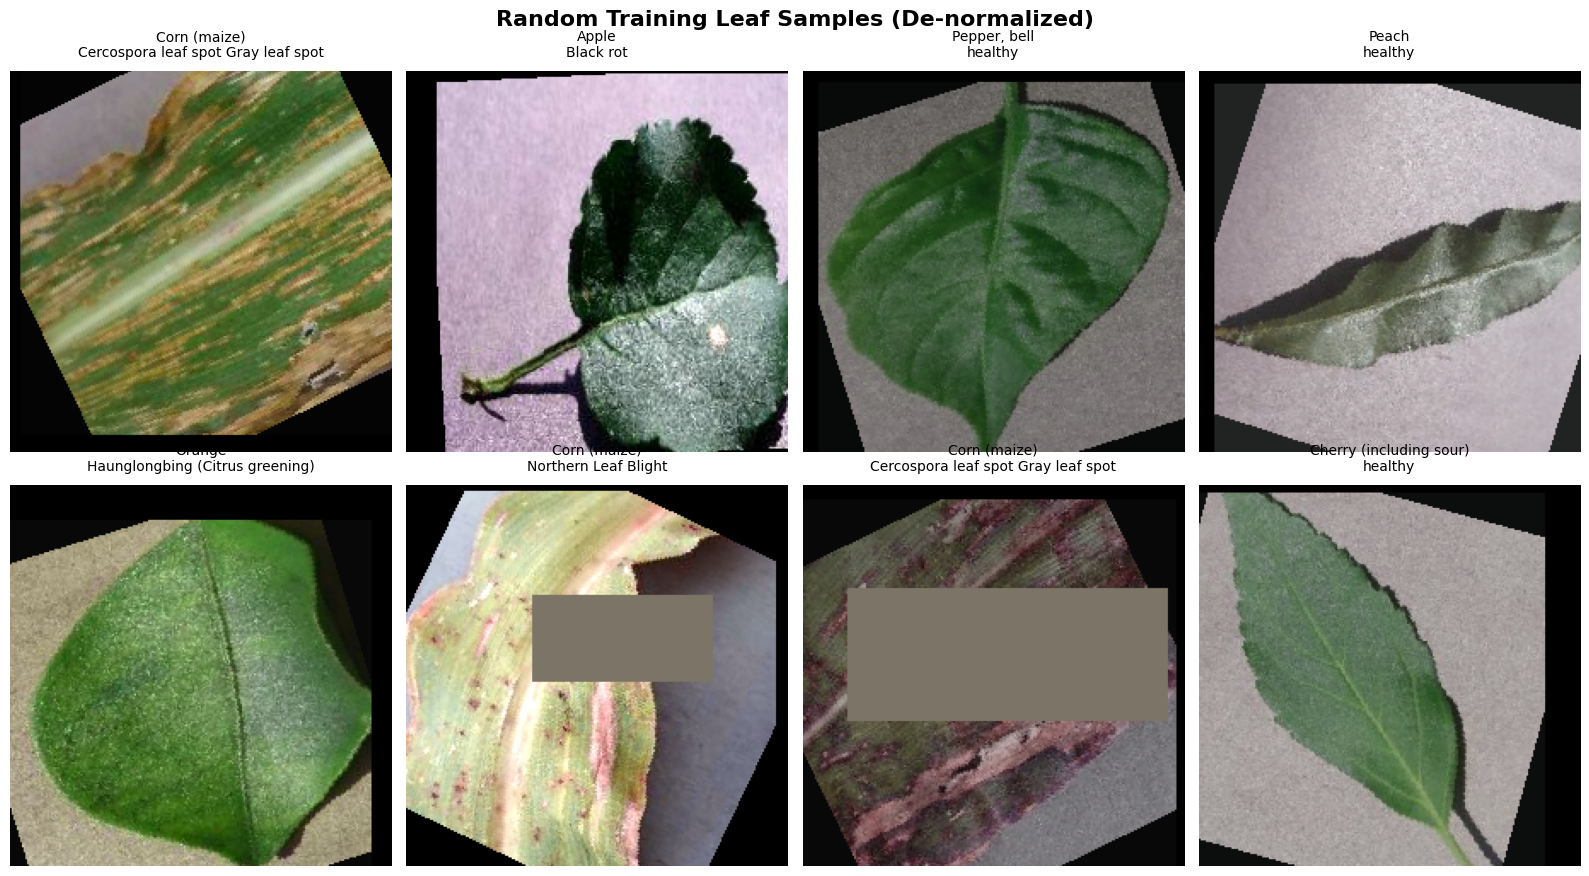

In [5]:
def show_random_samples(dataset, class_names, num_samples=8):
    plt.figure(figsize=(16, 9))
    indices = random.sample(range(len(dataset)), num_samples)
    for i, idx in enumerate(indices):
        img_tensor, label_idx = dataset[idx]
        
        # De-normalize image
        img = img_tensor.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        # Wrap title to prevent overlapping
        title = class_names[label_idx].replace("___", "\n").replace("_", " ")
        plt.title(title, fontsize=10, pad=10)
        plt.axis("off")
    plt.suptitle("Random Training Leaf Samples (De-normalized)", fontsize=16, weight="bold")
    plt.tight_layout()
    plt.show()

# Show samples
if 'train_ds' in locals():
    show_random_samples(train_ds, class_names)

## 3. Model Architecture (EfficientNetB3 + Custom Head)

We employ transfer learning by using **EfficientNet-B3** pre-trained on ImageNet. 
To adapt it for our 38 classes, we swap the standard head with a multi-layer classifier that includes Batch Normalization, Swish activations (SiLU), and Dropout to reduce overfitting.

Initially, we **freeze** the backbone layers (features) so that we only train our custom classifier head and don't destroy the pre-trained weights. After a few epochs (`UNFREEZE_EPOCH`), we **unfreeze** the backbone and perform fine-tuning with a very small learning rate (`LR_BACKBONE`).

In [6]:
class PlantDiseaseClassifier(nn.Module):
    def __init__(self, num_classes: int, pretrained: bool = True):
        super().__init__()
        # Load backbone
        weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.efficientnet_b3(weights=weights)

        # Extract features and average pooling
        self.features   = backbone.features
        self.avgpool    = backbone.avgpool
        in_features     = backbone.classifier[1].in_features   # 1536 for B3

        # Custom classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),                          # Swish activation
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(cfg.DROPOUT / 2),
            nn.Linear(256, num_classes),
        )

        # Freeze backbone initially
        self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.features.parameters():
            p.requires_grad = False
            
    def unfreeze_backbone(self):
        """Progressively unfreeze deeper layers for fine-tuning."""
        for p in self.features.parameters():
            p.requires_grad = True
        print("[Model] Backbone unfrozen for fine-tuning.")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

    def get_feature_maps(self, x: torch.Tensor):
        return self.features(x)

    def count_parameters(self):
        total   = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"[Model] Total params: {total:,}  |  Trainable: {trainable:,}")

# Initialize model
if 'class_names' in locals():
    model = PlantDiseaseClassifier(num_classes=len(class_names), pretrained=cfg.PRETRAINED)
    model.count_parameters()

[Model] Total params: 11,625,806  |  Trainable: 929,574


## 4. Training Engine & Setup

We implement the training loop inside a `Trainer` class. It manages:
1. **CrossEntropyLoss** with **Label Smoothing (0.1)** to encourage the model to be less overconfident and generalise better.
2. **AdamW Optimizer** with dual parameter groups (different learning rates for backbone vs classifier).
3. **Cosine Annealing Learning Rate Scheduler** to smoothly decay learning rate.
4. **Mixed Precision Training (torch.cuda.amp)** for significantly faster training and lower VRAM usage.
5. **Early Stopping** to stop training if validation accuracy doesn't improve for `EARLY_STOP_PAT` epochs.

In [7]:
class Trainer:
    def __init__(self, model, train_loader, val_loader, class_names):
        self.model        = model.to(cfg.DEVICE)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.class_names  = class_names
        self.history      = {"train_loss": [], "val_loss": [],
                             "train_acc":  [], "val_acc":  []}
        self.best_val_acc = 0.0
        self.no_improve   = 0

        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

        # Separate classifier params (higher LR) and backbone params (lower LR)
        self.optimizer = optim.AdamW([
            {"params": model.classifier.parameters(), "lr": cfg.LR},
            {"params": model.features.parameters(),   "lr": cfg.LR_BACKBONE},
        ], weight_decay=cfg.WEIGHT_DECAY)

        self.scheduler = CosineAnnealingLR(self.optimizer, T_max=cfg.EPOCHS, eta_min=1e-6)
        self.scaler    = torch.cuda.amp.GradScaler(enabled=(cfg.DEVICE == "cuda"))

    def train_epoch(self) -> tuple[float, float]:
        self.model.train()
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in self.train_loader:
            imgs, labels = imgs.to(cfg.DEVICE), labels.to(cfg.DEVICE)
            self.optimizer.zero_grad()
            
            with torch.cuda.amp.autocast(enabled=(cfg.DEVICE == "cuda")):
                outputs = self.model(imgs)
                loss    = self.criterion(outputs, labels)
                
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
        return total_loss / total, correct / total

    @torch.no_grad()
    def val_epoch(self) -> tuple[float, float]:
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in self.val_loader:
            imgs, labels = imgs.to(cfg.DEVICE), labels.to(cfg.DEVICE)
            outputs = self.model(imgs)
            loss    = self.criterion(outputs, labels)
            
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
        return total_loss / total, correct / total

    def fit(self):
        print(f"\nTraining Model on {cfg.DEVICE}...")
        self.model.count_parameters()

        for epoch in range(1, cfg.EPOCHS + 1):
            # Progressive unfreeze of backbone
            if epoch == cfg.UNFREEZE_EPOCH:
                self.model.unfreeze_backbone()

            t_loss, t_acc = self.train_epoch()
            v_loss, v_acc = self.val_epoch()
            self.scheduler.step()

            self.history["train_loss"].append(t_loss)
            self.history["val_loss"].append(v_loss)
            self.history["train_acc"].append(t_acc)
            self.history["val_acc"].append(v_acc)

            # Checkpoint
            if v_acc > self.best_val_acc:
                self.best_val_acc = v_acc
                self.no_improve   = 0
                torch.save({"epoch": epoch,
                            "model_state": self.model.state_dict(),
                            "class_names": self.class_names,
                            "val_acc": v_acc},
                           cfg.MODEL_SAVE_PATH)
                flag = "✓ Checkpoint Saved"
            else:
                self.no_improve += 1
                flag = f"(no improvement {self.no_improve}/{cfg.EARLY_STOP_PAT})"

            print(f"Epoch {epoch:2d}/{cfg.EPOCHS} | "
                  f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} │ "
                  f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f} │ {flag}")

            # Early stopping check
            if self.no_improve >= cfg.EARLY_STOP_PAT:
                print(f"\n[Early Stop] Training stopped early at epoch {epoch}.")
                break

        print(f"\n[Finished] Best Validation Accuracy: {self.best_val_acc:.4f}")
        return self.history

## 5. Execute Model Training

Run the cell below to begin training the network. 
*Note: If you are running on a CPU, training might take standard hours, so you might want to adjust `cfg.EPOCHS` in the configuration cell to a lower number like 2 or 3 for testing.*

## 6. Model Evaluation

Once training finishes, let's load the best saved model state and evaluate its performance against the held-out test dataset. We'll generate:
1. **Accuracy and Loss curves** over the training epochs.
2. **Classification Report** detailing Precision, Recall, and F1-score for all 38 classes.
3. **Confusion Matrix** to see exactly which classes our model gets confused by.

In [ ]:
@torch.no_grad()
def evaluate(model, test_loader, class_names, save_dir=cfg.RESULTS_DIR):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in test_loader:
        imgs   = imgs.to(cfg.DEVICE)
        preds  = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    print("\n" + "="*70)
    print("  CLASSIFICATION REPORT")
    print("="*70)
    print(classification_report(all_labels, all_preds,
                                target_names=class_names, digits=4))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(22, 20))
    sns.heatmap(cm, annot=False, fmt="d", cmap="YlOrRd",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title("Confusion Matrix – Plant Disease Prediction", fontsize=18, pad=15)
    ax.set_xlabel("Predicted Label", fontsize=14)
    ax.set_ylabel("True Label",    fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0,  fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/confusion_matrix.png", dpi=150)
    plt.show()
    print(f"[Eval] Confusion matrix plot saved → {save_dir}/confusion_matrix.png")

def plot_training_history(history, save_dir=cfg.RESULTS_DIR):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Training History – Plant Disease Classifier", fontsize=16, weight="bold")

    axes[0].plot(history["train_loss"], label="Train Loss", color="#2ecc71", lw=2.5)
    axes[0].plot(history["val_loss"],   label="Val Loss",   color="#e74c3c", lw=2.5)
    axes[0].set_title("Loss", fontsize=14); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_xlabel("Epoch")

    axes[1].plot(history["train_acc"], label="Train Acc", color="#2ecc71", lw=2.5)
    axes[1].plot(history["val_acc"],   label="Val Acc",   color="#e74c3c", lw=2.5)
    axes[1].set_title("Accuracy", fontsize=14); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_xlabel("Epoch")

    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_history.png", dpi=150)
    plt.show()
    print(f"[Plot] Training history plot saved → {save_dir}/training_history.png")

# Run evaluation on the best checkpoint
if os.path.exists(cfg.MODEL_SAVE_PATH) and 'test_loader' in locals():
    print(f"Loading best model checkpoint from '{cfg.MODEL_SAVE_PATH}'...")
    ckpt = torch.load(cfg.MODEL_SAVE_PATH, map_location=cfg.DEVICE)
    
    # Reload model weights
    best_model = PlantDiseaseClassifier(num_classes=len(class_names), pretrained=False)
    best_model.load_state_dict(ckpt["model_state"])
    best_model.to(cfg.DEVICE)
    
    if 'history' in locals():
        plot_training_history(history)
        
    evaluate(best_model, test_loader, class_names)
else:
    print("Best model checkpoint not found or test loader not available. Complete the training first.")

## 7. Model Explainability using Grad-CAM

A common issue in deep learning is the "black-box" nature of CNNs. We don't know if the model is actually looking at the leaf disease spot or just memorizing the background soil/lighting.

We use **Grad-CAM** (Gradient-weighted Class Activation Mapping). It uses gradients of any target class flowing into the final convolutional layer to produce a coarse localization map highlighting the important regions in the image.

In [8]:
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model        = model
        self.gradients    = None
        self.activations  = None
        # Register hooks
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, _, __, output):
        self.activations = output.detach()

    def _save_gradient(self, _, __, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, img_tensor: torch.Tensor, class_idx: int = None):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(cfg.DEVICE)
        output     = self.model(img_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(1).item()
            
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam).squeeze().cpu().numpy()
        
        # Min-Max Normalization
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

def visualize_gradcam(model, img_path: str, class_names: list, save_path: str = f"{cfg.RESULTS_DIR}/gradcam.png"):
    # Target the very last convolutional block of EfficientNet-B3 features
    target_layer = model.features[-1]
    gcam = GradCAM(model, target_layer)

    transform = get_transforms("val")
    img_pil    = Image.open(img_path).convert("RGB")
    img_tensor = transform(img_pil)

    cam, pred_idx = gcam.generate(img_tensor)
    cam_resized   = np.array(Image.fromarray(cam).resize(img_pil.size, Image.BILINEAR))

    heatmap = cm.jet(cam_resized)[..., :3]
    overlay = 0.5 * np.array(img_pil) / 255.0 + 0.5 * heatmap

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    axes[0].imshow(img_pil)
    axes[0].set_title("Original Leaf Image", fontsize=12)
    
    axes[1].imshow(cam_resized, cmap="jet")
    axes[1].set_title("Grad-CAM Attention Heatmap", fontsize=12)
    
    axes[2].imshow(np.clip(overlay, 0, 1))
    pred_label = class_names[pred_idx].replace("___", "\n").replace("_", " ")
    axes[2].set_title(f"Prediction:\n{pred_label}", fontsize=12, color="green" if "healthy" in pred_label.lower() else "red")
    
    for ax in axes: 
        ax.axis("off")
        
    plt.suptitle("Model Explainability with Grad-CAM", fontsize=15, weight="bold", y=0.98)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Grad-CAM] Visualization saved → {save_path}")

# Run Grad-CAM on a random image from the validation set
if 'best_model' in locals() and 'val_ds' in locals():
    valid_folder_path = os.path.join(cfg.DATA_DIR, "valid")
    all_images = list(Path(valid_folder_path).rglob("*.jpg")) + list(Path(valid_folder_path).rglob("*.JPG")) + list(Path(valid_folder_path).rglob("*.png"))
    
    if all_images:
        random_img_path = str(random.choice(all_images))
        print(f"Running Grad-CAM on random validation image: {random_img_path}")
        visualize_gradcam(best_model, random_img_path, class_names)
    else:
        print("No images found in valid folder structure to run Grad-CAM.")

## 8. Real-world Inference Pipeline

In production, you want a simple class that can load the checkpoint and predict leaf categories for any arbitrary file on disk.

The cell below defines the `PlantDiseasePredictor` helper class and demonstrates how to run inference on a new leaf image.

In [9]:
class PlantDiseasePredictor:
    def __init__(self, checkpoint_path: str):
        ckpt         = torch.load(checkpoint_path, map_location=cfg.DEVICE)
        self.classes = ckpt["class_names"]
        self.model   = PlantDiseaseClassifier(num_classes=len(self.classes), pretrained=False)
        self.model.load_state_dict(ckpt["model_state"])
        self.model.to(cfg.DEVICE).eval()
        self.transform = get_transforms("val")
        print(f"[Predictor] Loaded model successfully with {len(self.classes)} classes.")

    @torch.no_grad()
    def predict(self, img_path: str, top_k: int = 5) -> dict:
        img    = Image.open(img_path).convert("RGB")
        tensor = self.transform(img).unsqueeze(0).to(cfg.DEVICE)
        logits = self.model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]
        top_probs, top_idx = probs.topk(top_k)

        results = {
            "predicted_class":      self.classes[top_idx[0].item()],
            "confidence":           round(top_probs[0].item() * 100, 2),
            "top_k_predictions": [
                {"class": self.classes[i.item()],
                 "probability": round(p.item() * 100, 2)}
                for i, p in zip(top_idx, top_probs)
            ]
        }
        return results

# Demonstration usage
if os.path.exists(cfg.MODEL_SAVE_PATH):
    predictor = PlantDiseasePredictor(cfg.MODEL_SAVE_PATH)
    
    # Run prediction on the same random image we picked for Grad-CAM
    if 'random_img_path' in locals() and os.path.exists(random_img_path):
        result = predictor.predict(random_img_path)
        print("\nPrediction Results:")
        print(json.dumps(result, indent=2))

[Predictor] Loaded model successfully with 38 classes.
